[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-geophysics-edu/ess314/blob/main/notebooks/subduction_parameter_space.ipynb)

# Companion Notebook — Subduction Zones in Parameter Space

**ESS 314 · Lecture 28 (Convergent Plate Boundaries)**

This notebook is the interactive companion to Lecture 28. It rebuilds the
lecture's centerpiece figure (the age–rate–sediment classification space),
lets you reposition any margin and test the Ruff–Kanamori (1980) correlation
for yourself, and works the quantitative classification of three margins
(Chile, Mariana, Cascadia).

## Learning Objectives

By the end of this notebook, you will be able to:

- **[LO-1]** Load a per-zone subduction database and plot subduction zones in the
  classic age–rate classification space, colour-coded by maximum magnitude.
- **[LO-3]** Quantify the (absence of) correlation between maximum magnitude and
  the classic parameters, and contrast it with a second-order control
  (sediment thickness).
- **[LO-3]** Compute the thermal parameter $\Phi = A\,v_c\,\sin\delta$ and test
  whether it separates the great earthquakes from the rest.
- **[LO-3]** Estimate, from the seismic-moment relation, the rupture area and
  length required for an $M_w\,9$ earthquake, and compare to real margins.

## Prerequisites

- Lecture 28 (read first — this notebook assumes its framing).
- The open-data workflow of the Lecture 26 companion material.
- Basic `numpy` / `matplotlib` / `pandas`.


## 0. Setup

We use only standard scientific-Python libraries. The plotting style block below
is the ESS 314 course quality gate: a minimum readable font size and the
colourblind-safe Wong (2011) palette, so every figure in the course is legible
and accessible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- ESS 314 plotting quality gate -----------------------------------------
mpl.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "figure.dpi": 120,
})

# Colourblind-safe palette (Wong 2011)
BLUE, ORANGE, SKY, GREEN, VERM, PINK, BLACK = (
    "#0072B2", "#E69F00", "#56B4E9", "#009E73", "#D55E00", "#CC79A7", "#000000")

print("Setup complete.")

Setup complete.


## 1. The subduction-zone database

The table below is the per-zone compilation behind the lecture's parameter-space
figure. Each row is a major subduction segment with four quantities:

| column | meaning | units |
|--------|---------|-------|
| `age_Ma`  | incoming-plate age at the trench | Ma |
| `rate_mm_yr` | plate-to-plate convergence rate | mm/yr |
| `sediment_km` | trench sediment thickness | km |
| `Mw_max` | maximum observed (or paleoseismic) moment magnitude | — |

**Data provenance.** These values are representative, literature-compiled, and
rounded for teaching — they are *not* a substitute for the primary databases.
Age and convergence rate follow global compilations consistent with the MORVEL
plate-motion model (DeMets et al. 2010) and the SubMap / Heuret & Lallemand
database; trench sediment thickness is read from GlobSed (Straume et al. 2019,
doi:10.1029/2018GC008115); maximum magnitudes are from the USGS / Global CMT
record as summarised by Wirth et al. (2022, doi:10.1038/s43017-021-00245-w).

> **In your own environment:** you can regenerate every column from open data —
> `age_Ma` from the Müller/Seton age grid sampled at the trench, `sediment_km`
> from the GlobSed netCDF, slab dip and seismogenic width from Slab2
> (doi:10.5066/F7PV6JNV), and `Mw_max` from the Global CMT catalogue. The curated
> table here lets the notebook run offline; the Going Further section sketches
> the live-data version.

In [2]:
# Per-zone subduction database (representative, literature-compiled; see provenance).
zones = pd.DataFrame([
    # name,                   age_Ma, rate_mm_yr, sediment_km, Mw_max
    ("S. Chile (1960)",          20,    74,   1.3,  9.5),
    ("Alaska (1964)",            48,    57,   3.5,  9.2),
    ("Sumatra-Andaman (2004)",   55,    45,   2.5,  9.1),
    ("Tohoku (2011)",           130,    83,   0.5,  9.1),
    ("Kamchatka (1952)",         95,    80,   1.0,  9.0),
    ("Cascadia (1700)",          10,    40,   3.0,  9.0),
    ("Maule, Chile (2010)",      33,    68,   1.0,  8.8),
    ("Ecuador-Colombia (1906)",  18,    55,   1.5,  8.8),
    ("Aleutians (1957)",         55,    65,   1.5,  8.6),
    ("Kuril (1963)",            110,    82,   1.0,  8.5),
    ("Nankai (1707)",            20,    55,   2.0,  8.4),
    ("N. Chile/Peru",            48,    65,   0.2,  8.4),
    ("Sunda/Java",              110,    65,   1.2,  7.8),
    ("New Hebrides",             45,   110,   0.5,  7.9),
    ("Tonga",                   130,   165,   0.4,  8.0),
    ("Kermadec",                100,    55,   0.4,  8.1),
    ("Izu-Bonin",               145,    50,   0.4,  7.4),
    ("Mariana",                 155,    35,   0.4,  7.3),
], columns=["name", "age_Ma", "rate_mm_yr", "sediment_km", "Mw_max"])

zones

,name,age_Ma,rate_mm_yr,sediment_km,Mw_max
0,S. Chile (1960),20,74,1.3,9.5
1,Alaska (1964),48,57,3.5,9.2
2,Sumatra-Andaman (2004),55,45,2.5,9.1
3,Tohoku (2011),130,83,0.5,9.1
4,Kamchatka (1952),95,80,1.0,9.0
5,Cascadia (1700),10,40,3.0,9.0
6,"Maule, Chile (2010)",33,68,1.0,8.8
7,Ecuador-Colombia (1906),18,55,1.5,8.8
8,Aleutians (1957),55,65,1.5,8.6
9,Kuril (1963),110,82,1.0,8.5


## 2. The classic classification space

Plot the margins in age–rate space, sized and coloured by maximum magnitude. The
dashed box marks where Ruff & Kanamori (1980) predicted the largest earthquakes:
**old** incoming plate (right) and **fast** convergence (top), i.e. a strongly
coupled margin. The hypothesis was that great earthquakes should cluster there.

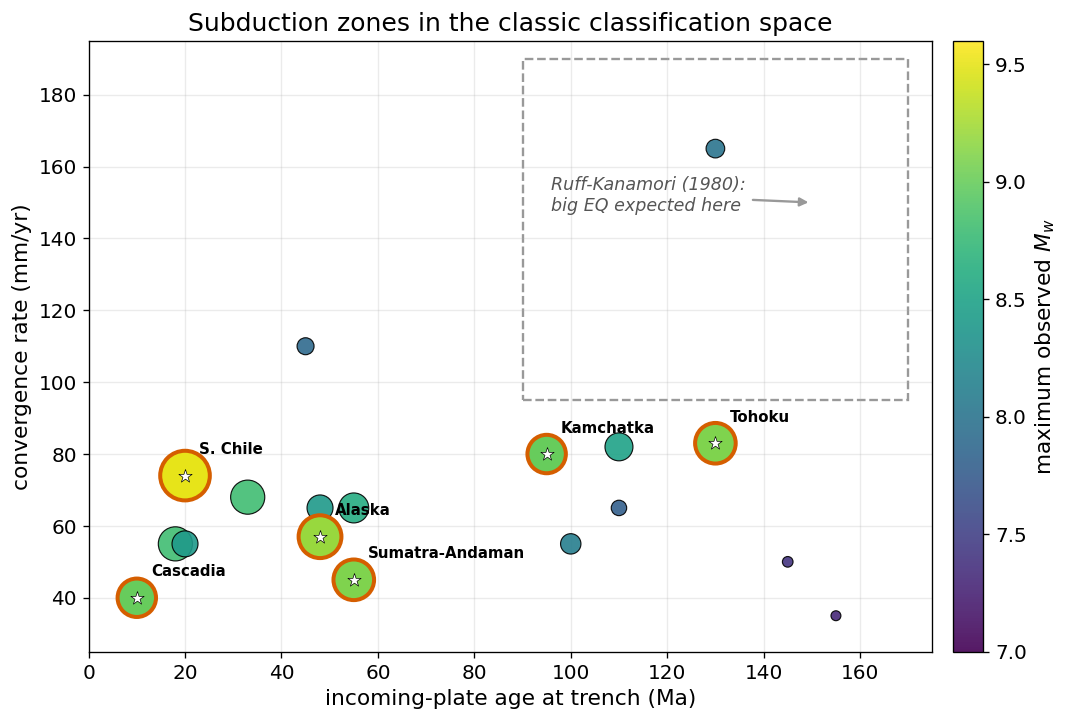

In [3]:
def marker_size(mw):
    # Emphasise the great events: area grows steeply with magnitude.
    return 30 + (mw - 7.0) ** 2.4 * 95.0

great = zones["Mw_max"] >= 8.95   # the M~9 club

fig, ax = plt.subplots(figsize=(9.5, 6.2))

# non-great events
sc = ax.scatter(zones.loc[~great, "age_Ma"], zones.loc[~great, "rate_mm_yr"],
                s=marker_size(zones.loc[~great, "Mw_max"]),
                c=zones.loc[~great, "Mw_max"], cmap="viridis",
                vmin=7.0, vmax=9.6, edgecolor=BLACK, lw=0.7, alpha=0.9, zorder=3)
# great events: ringed + starred
ax.scatter(zones.loc[great, "age_Ma"], zones.loc[great, "rate_mm_yr"],
           s=marker_size(zones.loc[great, "Mw_max"]),
           c=zones.loc[great, "Mw_max"], cmap="viridis", vmin=7.0, vmax=9.6,
           edgecolor=VERM, lw=2.4, zorder=4)
ax.scatter(zones.loc[great, "age_Ma"], zones.loc[great, "rate_mm_yr"],
           marker="*", s=70, color="white", edgecolor=BLACK, lw=0.4, zorder=5)

cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label("maximum observed $M_w$")

# the Ruff-Kanamori "recipe" box: old + fast
ax.add_patch(plt.Rectangle((90, 95), 80, 95, fill=False, ls="--",
                           ec="#999999", lw=1.4, zorder=1))
ax.annotate("Ruff-Kanamori (1980):\nbig EQ expected here",
            xy=(150, 150), xytext=(96, 152), ha="left", va="center",
            fontsize=10.5, color="#555555", style="italic",
            arrowprops=dict(arrowstyle="-|>", color="#999999", lw=1.4))

# label the great events
for _, r in zones[great].iterrows():
    ax.annotate(r["name"].split(" (")[0], xy=(r.age_Ma, r.rate_mm_yr),
                xytext=(r.age_Ma + 3, r.rate_mm_yr + 6), fontsize=9,
                fontweight="bold")

ax.set_xlabel("incoming-plate age at trench (Ma)")
ax.set_ylabel("convergence rate (mm/yr)")
ax.set_xlim(0, 175); ax.set_ylim(25, 195)
ax.set_title("Subduction zones in the classic classification space")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

**Read the figure.** The great ($M\geq 9$) earthquakes — the ringed stars —
do not cluster in the dashed "recipe" box. They are scattered across the entire
plane: young-and-slow (Cascadia), young-and-fast (Chile), old-and-slow (Sumatra),
old-and-fast (Tōhoku). The box the 1980 hypothesis pointed to is essentially
empty. This is the lecture's central claim, made directly from the data.

If anything, the largest events in this compilation lean slightly toward the
*young* (left) side — the opposite of the recipe — which Exercise 1 makes
quantitative. With only ~18 margins, no parameter here is a stable predictor;
the absence of the predicted clustering is the robust result, not any particular
correlation coefficient.

### Exercise 1 — Quantify the (non-)correlation

If the Ruff–Kanamori recipe held, $M_w^{\max}$ would rise with **both** age and
rate (older + faster = bigger). Compute the Pearson correlations and check the
**sign** as well as the strength of each.

In [4]:
# Exercise 1: correlation of Mw_max with each classic parameter.
for col in ["age_Ma", "rate_mm_yr", "sediment_km"]:
    r = np.corrcoef(zones[col], zones["Mw_max"])[0, 1]
    print(f"corr(Mw_max, {col:12s}) = {r:+.2f}")

# QUESTION (write your answer as a comment):
# The recipe predicts POSITIVE correlation with both age and rate. What sign do
# you actually find for age? (It is negative in this compilation — older plates
# trend toward SMALLER maxima here, the opposite of the prediction.) Rate is
# near zero. Which parameter correlates most strongly, and in which direction?
# Is ANY of these strong and correctly-signed enough to predict a margin's Mmax?
# What does that imply for a margin with no recorded great earthquake?
#
# CAUTION: with only ~18 zones these coefficients are not robust — resampling a
# different set of margins can swing them. That fragility is itself the point:
# the "controls" are not stable predictors.

corr(Mw_max, age_Ma      ) = -0.61
corr(Mw_max, rate_mm_yr  ) = -0.07
corr(Mw_max, sediment_km ) = +0.57


## 3. The thermal parameter

The lecture combined age, rate, and dip into the **thermal parameter**

$$\Phi = A \, v_c \, \sin\delta,$$

a measure of how cold the slab stays as it descends. Large $\Phi$ (old, fast,
steep) was the quantitative version of the "strong coupling" expectation. Does
$\Phi$ separate the great earthquakes from the rest any better than age and rate
did on their own?

We need a dip for each margin. The table below adds a representative deep-slab
dip; in your own environment you would read this from Slab2.

In [5]:
# Representative deep-slab dips (deg), consistent with Lallemand et al. (2005)
# and Slab2. Rounded for teaching.
dip_deg = {
    "S. Chile (1960)": 20, "Alaska (1964)": 30, "Sumatra-Andaman (2004)": 30,
    "Tohoku (2011)": 32, "Kamchatka (1952)": 40, "Cascadia (1700)": 22,
    "Maule, Chile (2010)": 22, "Ecuador-Colombia (1906)": 28,
    "Aleutians (1957)": 45, "Kuril (1963)": 42, "Nankai (1707)": 22,
    "N. Chile/Peru": 25, "Sunda/Java": 48, "New Hebrides": 58, "Tonga": 60,
    "Kermadec": 55, "Izu-Bonin": 62, "Mariana": 78,
}
zones["dip_deg"] = zones["name"].map(dip_deg)

# thermal parameter Phi = A * v * sin(dip)   (units: Ma * mm/yr -> scaled)
zones["Phi"] = (zones["age_Ma"] * zones["rate_mm_yr"]
                * np.sin(np.radians(zones["dip_deg"])))

zones[["name", "age_Ma", "rate_mm_yr", "dip_deg", "Phi", "Mw_max"]] \
    .sort_values("Phi", ascending=False).reset_index(drop=True)

,name,age_Ma,rate_mm_yr,dip_deg,Phi,Mw_max
0,Tonga,130,165,60,18576.244911,8.0
1,Izu-Bonin,145,50,62,6401.370048,7.4
2,Kuril (1963),110,82,42,6035.558069,8.5
3,Tohoku (2011),130,83,32,5717.828861,9.1
4,Sunda/Java,110,65,48,5313.485502,7.8
5,Mariana,155,35,78,5306.450734,7.3
6,Kamchatka (1952),95,80,40,4885.185834,9.0
7,Kermadec,100,55,55,4505.336244,8.1
8,New Hebrides,45,110,58,4197.838076,7.9
9,Aleutians (1957),55,65,45,2527.906743,8.6


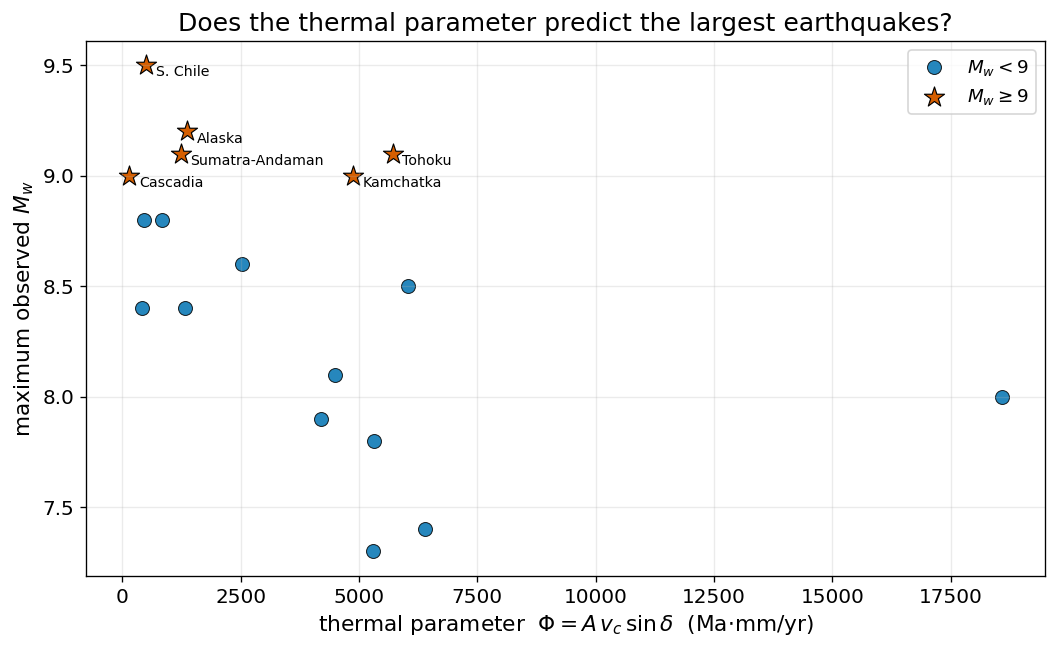

corr(Mw_max, Phi) = -0.47


In [6]:
# Plot Mw_max against the thermal parameter.
fig, ax = plt.subplots(figsize=(9, 5.6))
ax.scatter(zones.loc[~great, "Phi"], zones.loc[~great, "Mw_max"],
           s=70, c=BLUE, edgecolor=BLACK, lw=0.6, alpha=0.85, label="$M_w<9$")
ax.scatter(zones.loc[great, "Phi"], zones.loc[great, "Mw_max"],
           s=160, marker="*", c=VERM, edgecolor=BLACK, lw=0.7,
           label=r"$M_w\geq 9$")
for _, r in zones[great].iterrows():
    ax.annotate(r["name"].split(" (")[0], xy=(r.Phi, r.Mw_max),
                xytext=(r.Phi + 200, r.Mw_max - 0.05), fontsize=8.5)
ax.set_xlabel(r"thermal parameter  $\Phi = A\,v_c\,\sin\delta$  (Ma$\cdot$mm/yr)")
ax.set_ylabel("maximum observed $M_w$")
ax.set_title("Does the thermal parameter predict the largest earthquakes?")
ax.grid(alpha=0.25); ax.legend()
fig.tight_layout()
plt.show()

r_phi = np.corrcoef(zones["Phi"], zones["Mw_max"])[0, 1]
print(f"corr(Mw_max, Phi) = {r_phi:+.2f}")

Notice that the great earthquakes span almost the full range of $\Phi$ —
Cascadia and Chile sit at *low* $\Phi$ (young, warm slabs), Tōhoku and Kamchatka
at high $\Phi$. Combining the parameters into $\Phi$ does not rescue the
hypothesis: a cold slab is not a prerequisite for a great earthquake.

### Exercise 2 — Reposition a margin

Suppose a new global compilation revises the Mariana incoming-plate age downward
and finds the margin actually hosted a great earthquake in prehistory. Edit a
copy of the table to set Mariana's `Mw_max` to 9.0, re-plot the age–rate space,
and describe how it changes the picture. *Does one reclassified margin rescue or
further undermine the age/rate hypothesis?*

In [7]:
# Exercise 2: your code here.
# Hint: zones2 = zones.copy(); zones2.loc[zones2.name=="Mariana","Mw_max"] = 9.0
# then repeat the Section-2 scatter with zones2. Write your interpretation as a
# comment below the plot.


## 4. A second-order control: sediment smoothing

The modern view replaces age and rate with controls on the *geometry and
homogeneity* of the seismogenic zone. One of these is trench sediment: a thick,
well-consolidated sediment section can smooth the megathrust, removing the
seamount and ridge barriers that would otherwise stop a rupture, letting it run
farther along strike and grow larger.

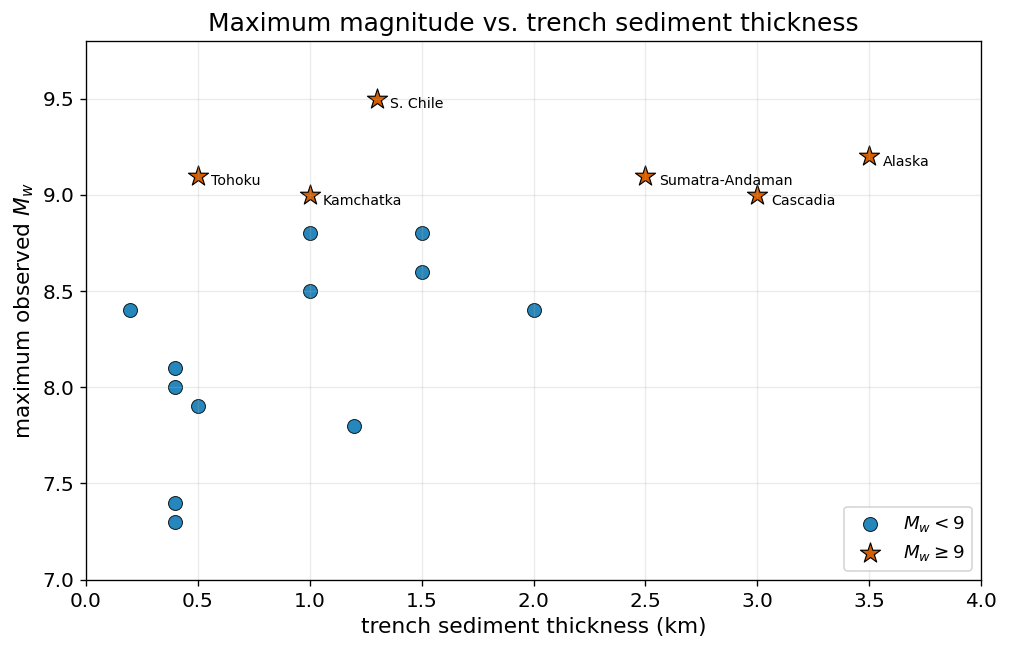

In [8]:
fig, ax = plt.subplots(figsize=(8.6, 5.6))
ax.scatter(zones.loc[~great, "sediment_km"], zones.loc[~great, "Mw_max"],
           s=70, c=BLUE, edgecolor=BLACK, lw=0.6, alpha=0.85, label="$M_w<9$")
ax.scatter(zones.loc[great, "sediment_km"], zones.loc[great, "Mw_max"],
           s=160, marker="*", c=VERM, edgecolor=BLACK, lw=0.7,
           label=r"$M_w\geq 9$")
for _, r in zones[great].iterrows():
    ax.annotate(r["name"].split(" (")[0], xy=(r.sediment_km, r.Mw_max),
                xytext=(r.sediment_km + 0.06, r.Mw_max - 0.05), fontsize=8.5)
ax.set_xlabel("trench sediment thickness (km)")
ax.set_ylabel("maximum observed $M_w$")
ax.set_xlim(0, 4); ax.set_ylim(7.0, 9.8)
ax.set_title("Maximum magnitude vs. trench sediment thickness")
ax.grid(alpha=0.25); ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

The great earthquakes favour sediment-rich margins — a tendency, not a law
(Tōhoku is sediment-poor, a reminder that no single parameter is sufficient).
The honest summary is that maximum magnitude is multi-causal, and the working
assumption is that **any mature megathrust may be $M\,9$-capable**.

## 5. How big a fault do you need for an $M_w\,9$?

The lecture's moment relation,

$$M_0 = \mu\,\bar D\,(L\,W), \qquad M_w = \tfrac{2}{3}\log_{10}M_0 - 6.07,$$

ties magnitude to rupture **area**. Invert it: how much fault area, and how much
along-strike length, does an $M_w\,9$ require? This is why margin *geometry*, not
slab age, sets the magnitude ceiling.

In [9]:
def Mw_to_M0(Mw):
    # Moment magnitude -> seismic moment (N m).
    return 10 ** (1.5 * (Mw + 6.07))

def rupture_length(Mw, mu=40e9, slip=15.0, width_km=100.0):
    # Along-strike length (km) for a given Mw, slip (m), seismogenic width (km).
    M0 = Mw_to_M0(Mw)
    area_m2 = M0 / (mu * slip)          # A = M0 / (mu * D)
    width_m = width_km * 1e3
    return area_m2 / width_m / 1e3      # km

for Mw in [8.0, 8.5, 9.0, 9.5]:
    L = rupture_length(Mw)
    print(f"Mw {Mw}:  rupture area = {Mw_to_M0(Mw)/(40e9*15)/1e6:7.0f} km^2,"
          f"  length (W=100 km, D=15 m) = {L:5.0f} km")

print("\nFor comparison: the Cascadia margin is ~1000-1100 km long.")

Mw 8.0:  rupture area =    2123 km^2,  length (W=100 km, D=15 m) =    21 km
Mw 8.5:  rupture area =   11936 km^2,  length (W=100 km, D=15 m) =   119 km
Mw 9.0:  rupture area =   67120 km^2,  length (W=100 km, D=15 m) =   671 km
Mw 9.5:  rupture area =  377441 km^2,  length (W=100 km, D=15 m) =  3774 km

For comparison: the Cascadia margin is ~1000-1100 km long.


An $M_w\,9$ with 15 m of average slip on a 100-km-wide seismogenic zone
requires a rupture roughly **700 km long**; relax the slip or widen the zone and
the required length grows toward the **full $\sim 1000$ km Cascadia margin**. The
point is the order of magnitude: an $M\,9$ needs a fault hundreds of kilometres
long and a wide locked zone — area a margin either has or does not. A short or
narrow seismogenic zone (e.g. steeply dipping Mariana) cannot assemble it,
regardless of slab age. Try `rupture_length(9.0, slip=10, width_km=80)` to see
how the length climbs as slip and width shrink.

### Exercise 3 — The width matters

Mariana's steep dip ($\sim 78^\circ$) gives it a narrow seismogenic width. Using
`rupture_length`, find the along-strike length needed for an $M_w\,9$ if the
seismogenic width is only $W = 30$ km (instead of 100 km). Is that length
physically plausible for the Mariana arc? What does this tell you about why
steep, weakly coupled margins do not host $M\,9$ earthquakes?

In [10]:
# Exercise 3: your code here.
# Hint: rupture_length(9.0, width_km=30.0)


## 6. Worked classification: Chile, Mariana, Cascadia

Pull the three margins from the lecture's §6 and tabulate the parameters that
matter, old and new, side by side.

In [11]:
picks = ["Maule, Chile (2010)", "Mariana", "Cascadia (1700)"]
view = zones[zones["name"].isin(picks)][
    ["name", "age_Ma", "rate_mm_yr", "dip_deg", "sediment_km", "Phi", "Mw_max"]
].copy()
view["RK_recipe_rank"] = ["high (old-ish, fast)", "high (very old)", "LOW (young, slow)"]
view["actual"] = ["M8.8/9.5 great", "no great EQ", "M~9 (1700)"]
view.reset_index(drop=True)

,name,age_Ma,rate_mm_yr,dip_deg,sediment_km,Phi,Mw_max,RK_recipe_rank,actual
0,Cascadia (1700),10,40,22,3.0,149.842637,9.0,"high (old-ish, fast)",M8.8/9.5 great
1,"Maule, Chile (2010)",33,68,22,1.0,840.617196,8.8,high (very old),no great EQ
2,Mariana,155,35,78,0.4,5306.450734,7.3,"LOW (young, slow)",M~9 (1700)


The three rows make the lecture's point quantitatively:

- **Chile** is high on the old recipe *and* produces great earthquakes — the
  recipe works here.
- **Mariana** is high on the old recipe (very old plate) but produces *no* great
  earthquakes — its steep dip gives a narrow seismogenic width (Exercise 3),
  and the recipe fails in one direction.
- **Cascadia** is *low* on the old recipe (young, slow) yet is $M\,9$-capable —
  thick sediment, a smooth wide interface, and full-margin rupture length, and
  the recipe fails in the other direction.

A classification that cannot accommodate all three is not capturing the
controlling physics — which is exactly the lecture's thesis.

## Going Further

1. **Live data.** Replace the curated table with primary sources. Sample the
   Müller/Seton age grid and the GlobSed sediment grid at trench locations with
   `xarray`; read slab dip and seismogenic width from the Slab2 grids
   (`*_dep.grd`, `*_dip.grd`; USGS data release doi:10.5066/F7PV6JNV); pull the
   great-earthquake catalogue from Global CMT. Rebuild the parameter space and
   see whether the (non-)correlation survives a fully independent compilation.

2. **Add a geometry axis.** The modern controls are geometric. Add seismogenic
   *width* $W$ (from Slab2 dip and a locking-depth assumption) as a fourth column
   and test `corr(Mw_max, W)`. Does width predict maximum magnitude better than
   age or rate?

3. **Recurrence.** Lay & Nishenko (2022, doi:10.1073/pnas.2216843119) revisit
   seismic gaps along South America. Pull the great-earthquake dates for the
   Chilean margin and estimate recurrence intervals — then ask whether
   "any margin is $M\,9$-capable" is in tension with observed cyclicity.

4. **Cascadia detail.** Han et al. (2017, doi:10.1038/s41561-017-0007-2) link
   along-strike sediment consolidation to locking at Cascadia. Sketch how you
   would test that with offshore data.

---

### References (open access preferred)

- Wirth, E. A. et al. (2022). *Nat. Rev. Earth Environ.* 3, 125–140.
  doi:10.1038/s43017-021-00245-w
- Ruff, L. & Kanamori, H. (1980). *Phys. Earth Planet. Inter.* 23, 240–252.
  doi:10.1016/0031-9201(80)90117-X
- Hayes, G. P. et al. (2018). Slab2. *Science* 362, 58–61.
  doi:10.1126/science.aat4723; data doi:10.5066/F7PV6JNV
- Straume, E. O. et al. (2019). GlobSed. *G-Cubed* 20, 1756–1772.
  doi:10.1029/2018GC008115
- Lallemand, S. et al. (2005). *G-Cubed* 6, Q09006. doi:10.1029/2005GC000917

*This notebook accompanies ESS 314 Lecture 28. Data values are representative
teaching compilations; see Section 1 for provenance.*